In [1]:
# ============================================================
# 1. IMPORTS
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json

from pathlib import Path

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from xgboost import XGBClassifier

import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42

In [2]:
# ============================================================
# 2. LOAD DATA & SELECTED FEATURES
# ============================================================

DATA_PATH = Path(
    "../data/processed/feature_engineered_data.csv"
)

FEATURE_PATH = Path(
    "../data/processed/selected_features.json"
)


df = pd.read_csv(DATA_PATH)

df["Date"] = pd.to_datetime(df["Date"])

df = (
    df.sort_values(["Date", "Symbol"])
      .reset_index(drop=True)
)


with open(FEATURE_PATH, "r") as f:
    features = json.load(f)


target = "Target_Direction"


print("Dataset Shape:", df.shape)

print(
    "Date Range:",
    df["Date"].min(),
    "→",
    df["Date"].max()
)

print(
    "Number of Stocks:",
    df["Symbol"].nunique()
)

print(
    "\nNumber of Selected Features:",
    len(features)
)

print("\nSelected Features:")

for i, feature in enumerate(features, 1):
    print(f"{i:02d}. {feature}")

Dataset Shape: (235192, 99)
Date Range: 2000-01-03 00:00:00 → 2021-04-30 00:00:00
Number of Stocks: 49

Number of Selected Features: 20

Selected Features:
01. Market_Return_LOO
02. Market_Breadth_LOO
03. DayOfWeek
04. Price_SMA_10_Ratio
05. Return_Lag_1
06. Relative_Sector_Return_LOO
07. Momentum_5
08. Sector_Return_LOO
09. ATR_14_Pct
10. Price_SMA_5_Ratio
11. Relative_Volume
12. Price_SMA_200_Ratio
13. Relative_Market_Return_LOO
14. Quarter
15. Return_Lag_3
16. Return_Lag_10
17. Close_Position
18. MACD_Histogram
19. Return_Lag_2
20. MACD


In [3]:
# ============================================================
# 3. CREATE MODELLING DATASET
# ============================================================

reference_cols = [
    "Date",
    "Symbol"
]

# Daily_Return is needed for momentum baseline
if "Daily_Return" not in features:
    reference_cols.append("Daily_Return")


model_columns = (
    reference_cols
    + features
    + [target]
)


model_df = df[
    model_columns
].copy()


model_df = model_df.replace(
    [np.inf, -np.inf],
    np.nan
)


print("Before removing missing values:")
print(model_df.shape)


model_df = (
    model_df
    .dropna(
        subset=features + [target]
    )
    .reset_index(drop=True)
)


print("\nAfter removing missing values:")
print(model_df.shape)

Before removing missing values:
(235192, 24)

After removing missing values:
(204277, 24)


In [4]:
# ============================================================
# 4. CHRONOLOGICAL TRAIN / VALIDATION / TEST SPLIT
# ============================================================

train_df = model_df[
    model_df["Date"] < "2018-01-01"
].copy()


val_df = model_df[
    (model_df["Date"] >= "2018-01-01") &
    (model_df["Date"] < "2020-01-01")
].copy()


test_df = model_df[
    model_df["Date"] >= "2020-01-01"
].copy()


print("TRAIN")
print(
    train_df["Date"].min(),
    "→",
    train_df["Date"].max()
)
print("Rows:", len(train_df))


print("\nVALIDATION")
print(
    val_df["Date"].min(),
    "→",
    val_df["Date"].max()
)
print("Rows:", len(val_df))


print("\nTEST — LOCKED")
print(
    test_df["Date"].min(),
    "→",
    test_df["Date"].max()
)
print("Rows:", len(test_df))

TRAIN
2000-10-19 00:00:00 → 2017-12-29 00:00:00
Rows: 168109

VALIDATION
2018-01-01 00:00:00 → 2019-12-31 00:00:00
Rows: 21604

TEST — LOCKED
2020-01-01 00:00:00 → 2021-04-29 00:00:00
Rows: 14564


In [5]:
X_train = train_df[features]
y_train = train_df[target].astype(int)

X_val = val_df[features]
y_val = val_df[target].astype(int)

X_test = test_df[features]
y_test = test_df[target].astype(int)


print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

X_train: (168109, 20)
X_val: (21604, 20)
X_test: (14564, 20)


In [6]:
# ============================================================
# 5. MAJORITY CLASS BASELINE
# ============================================================

majority_class = y_train.mode()[0]

majority_pred = np.full(
    len(y_val),
    majority_class
)


baseline_accuracy = accuracy_score(
    y_val,
    majority_pred
)


print("Majority Class:", majority_class)

print(
    "Baseline Accuracy:",
    round(baseline_accuracy, 4)
)

Majority Class: 1
Baseline Accuracy: 0.4987


In [7]:
# ============================================================
# 6. MOMENTUM / PREVIOUS-DAY DIRECTION BASELINE
# ============================================================

momentum_pred = (
    val_df["Daily_Return"] > 0
).astype(int)


momentum_accuracy = accuracy_score(
    y_val,
    momentum_pred
)


momentum_f1 = f1_score(
    y_val,
    momentum_pred
)


print(
    "Momentum Baseline Accuracy:",
    round(momentum_accuracy, 4)
)

print(
    "Momentum Baseline F1:",
    round(momentum_f1, 4)
)

Momentum Baseline Accuracy: 0.4864
Momentum Baseline F1: 0.4847


In [8]:
# ============================================================
# 7. MODEL EVALUATION FUNCTION
# ============================================================

def evaluate_model(
    name,
    model,
    X,
    y
):

    pred = model.predict(X)

    prob = model.predict_proba(X)[:, 1]


    metrics = {

        "Model": name,

        "Accuracy":
            accuracy_score(
                y,
                pred
            ),

        "Precision":
            precision_score(
                y,
                pred,
                zero_division=0
            ),

        "Recall":
            recall_score(
                y,
                pred,
                zero_division=0
            ),

        "F1":
            f1_score(
                y,
                pred,
                zero_division=0
            ),

        "ROC_AUC":
            roc_auc_score(
                y,
                prob
            )
    }


    return metrics

In [9]:
results = []

In [10]:
# ============================================================
# 8. LOGISTIC REGRESSION
# ============================================================

logistic_model = Pipeline([

    (
        "scaler",
        StandardScaler()
    ),

    (
        "model",
        LogisticRegression(
            max_iter=2000,
            random_state=RANDOM_STATE
        )
    )

])


logistic_model.fit(
    X_train,
    y_train
)


logistic_results = evaluate_model(
    "Logistic Regression",
    logistic_model,
    X_val,
    y_val
)


results.append(
    logistic_results
)


logistic_results

{'Model': 'Logistic Regression',
 'Accuracy': 0.5111090538789114,
 'Precision': 0.5082554517133956,
 'Recall': 0.6057174679784667,
 'F1': 0.5527229609553654,
 'ROC_AUC': 0.5145851534447091}

In [11]:
# ============================================================
# 9. RANDOM FOREST
# ============================================================

rf_model = RandomForestClassifier(

    n_estimators=300,

    max_depth=10,

    min_samples_split=20,

    min_samples_leaf=10,

    max_features="sqrt",

    class_weight="balanced",

    random_state=RANDOM_STATE,

    n_jobs=-1
)


rf_model.fit(
    X_train,
    y_train
)


rf_results = evaluate_model(
    "Random Forest",
    rf_model,
    X_val,
    y_val
)


results.append(
    rf_results
)


rf_results

{'Model': 'Random Forest',
 'Accuracy': 0.5144880577670802,
 'Precision': 0.514988955506469,
 'Recall': 0.4544273250417672,
 'F1': 0.48281642917015927,
 'ROC_AUC': 0.5262862648889182}

In [12]:
# ============================================================
# 10. XGBOOST
# ============================================================

xgb_model = XGBClassifier(

    n_estimators=400,

    learning_rate=0.03,

    max_depth=4,

    min_child_weight=10,

    subsample=0.8,

    colsample_bytree=0.8,

    reg_alpha=0.1,

    reg_lambda=1.0,

    eval_metric="logloss",

    random_state=RANDOM_STATE,

    n_jobs=-1
)


xgb_model.fit(
    X_train,
    y_train
)


xgb_results = evaluate_model(
    "XGBoost",
    xgb_model,
    X_val,
    y_val
)


results.append(
    xgb_results
)


xgb_results

{'Model': 'XGBoost',
 'Accuracy': 0.5224958341047954,
 'Precision': 0.5194298320040727,
 'Recall': 0.568219788379432,
 'F1': 0.5427304964539007,
 'ROC_AUC': 0.5314532300581356}

In [13]:
# ============================================================
# 11. MODEL COMPARISON
# ============================================================

results_df = (
    pd.DataFrame(results)
    .sort_values(
        "ROC_AUC",
        ascending=False
    )
    .reset_index(drop=True)
)


results_df

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,XGBoost,0.522496,0.519430,0.568220,0.542730,0.531453
1,Random Forest,0.514488,0.514989,0.454427,0.482816,0.526286
2,Logistic Regression,0.511109,0.508255,0.605717,0.552723,0.514585


In [14]:
# ============================================================
# 12. XGBOOST HYPERPARAMETER TUNING
# ============================================================

from itertools import product


param_grid = {

    "max_depth": [
        3, 4, 5
    ],

    "min_child_weight": [
        5, 10, 20
    ],

    "learning_rate": [
        0.02, 0.03, 0.05
    ],

    "subsample": [
        0.7, 0.8
    ],

    "colsample_bytree": [
        0.7, 0.8
    ]
}


tuning_results = []


combinations = list(
    product(
        param_grid["max_depth"],
        param_grid["min_child_weight"],
        param_grid["learning_rate"],
        param_grid["subsample"],
        param_grid["colsample_bytree"]
    )
)


print(
    "Total combinations:",
    len(combinations)
)

Total combinations: 108


In [15]:
for (
    max_depth,
    min_child_weight,
    learning_rate,
    subsample,
    colsample_bytree
) in combinations:

    model = XGBClassifier(

        n_estimators=400,

        max_depth=max_depth,

        min_child_weight=min_child_weight,

        learning_rate=learning_rate,

        subsample=subsample,

        colsample_bytree=colsample_bytree,

        reg_alpha=0.1,

        reg_lambda=1.0,

        eval_metric="logloss",

        random_state=RANDOM_STATE,

        n_jobs=-1
    )


    model.fit(
        X_train,
        y_train
    )


    pred = model.predict(
        X_val
    )

    prob = model.predict_proba(
        X_val
    )[:, 1]


    tuning_results.append({

        "max_depth":
            max_depth,

        "min_child_weight":
            min_child_weight,

        "learning_rate":
            learning_rate,

        "subsample":
            subsample,

        "colsample_bytree":
            colsample_bytree,

        "Accuracy":
            accuracy_score(
                y_val,
                pred
            ),

        "F1":
            f1_score(
                y_val,
                pred
            ),

        "ROC_AUC":
            roc_auc_score(
                y_val,
                prob
            )
    })

In [16]:
tuning_df = (
    pd.DataFrame(tuning_results)
    .sort_values(
        "ROC_AUC",
        ascending=False
    )
    .reset_index(drop=True)
)

tuning_df.head(10)

,max_depth,min_child_weight,learning_rate,subsample,colsample_bytree,Accuracy,F1,ROC_AUC
0,4,5,0.05,0.7,0.8,0.520320,0.541724,0.531981
1,5,20,0.03,0.8,0.8,0.521570,0.547579,0.531879
2,3,5,0.05,0.7,0.8,0.524162,0.544286,0.531866
3,4,5,0.03,0.8,0.8,0.521153,0.542317,0.531827
4,3,20,0.05,0.7,0.8,0.522959,0.543659,0.531799
5,4,10,0.03,0.7,0.8,0.520737,0.543756,0.531567
6,5,5,0.02,0.8,0.8,0.520737,0.543917,0.531515
7,4,10,0.03,0.8,0.8,0.522496,0.542730,0.531453
8,4,20,0.03,0.8,0.7,0.521894,0.544998,0.531438
9,4,20,0.03,0.8,0.8,0.521061,0.543441,0.531423


In [17]:
best_params = (
    tuning_df
    .iloc[0]
)

best_params

max_depth           4.000000
min_child_weight    5.000000
learning_rate       0.050000
subsample           0.700000
colsample_bytree    0.800000
Accuracy            0.520320
F1                  0.541724
ROC_AUC             0.531981
Name: 0, dtype: float64

In [18]:
best_xgb = XGBClassifier(

    n_estimators=400,

    max_depth=int(
        best_params["max_depth"]
    ),

    min_child_weight=int(
        best_params["min_child_weight"]
    ),

    learning_rate=float(
        best_params["learning_rate"]
    ),

    subsample=float(
        best_params["subsample"]
    ),

    colsample_bytree=float(
        best_params["colsample_bytree"]
    ),

    reg_alpha=0.1,

    reg_lambda=1.0,

    eval_metric="logloss",

    random_state=RANDOM_STATE,

    n_jobs=-1
)


best_xgb.fit(
    X_train,
    y_train
)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [19]:
best_val_results = evaluate_model(
    "Tuned XGBoost",
    best_xgb,
    X_val,
    y_val
)

best_val_results

{'Model': 'Tuned XGBoost',
 'Accuracy': 0.5203203110535086,
 'Precision': 0.5173578849564997,
 'Recall': 0.5684982364952664,
 'F1': 0.5417237872020519,
 'ROC_AUC': 0.5319809616564346}

In [20]:
# ============================================================
# 13. PROBABILITY THRESHOLD ANALYSIS
# ============================================================

val_prob = best_xgb.predict_proba(
    X_val
)[:, 1]


threshold_results = []


for threshold in np.arange(
    0.45,
    0.61,
    0.01
):

    pred = (
        val_prob >= threshold
    ).astype(int)


    threshold_results.append({

        "Threshold":
            round(threshold, 2),

        "Accuracy":
            accuracy_score(
                y_val,
                pred
            ),

        "Precision":
            precision_score(
                y_val,
                pred,
                zero_division=0
            ),

        "Recall":
            recall_score(
                y_val,
                pred,
                zero_division=0
            ),

        "F1":
            f1_score(
                y_val,
                pred,
                zero_division=0
            ),

        "Predicted_UP_Rate":
            pred.mean()
    })


threshold_df = pd.DataFrame(
    threshold_results
)

threshold_df

,Threshold,Accuracy,Precision,Recall,F1,Predicted_UP_Rate
0,0.45,0.507684,0.503454,0.933358,0.654091,0.924551
1,0.46,0.511202,0.505617,0.893911,0.645899,0.881689
2,0.47,0.518099,0.510212,0.841656,0.635303,0.822672
3,0.48,0.520922,0.513169,0.766753,0.614841,0.745140
4,0.49,0.522542,0.516273,0.675794,0.585360,0.652796
5,0.50,0.520320,0.517358,0.568498,0.541724,0.548000
6,0.51,0.521616,0.522838,0.466401,0.493010,0.444871
7,0.52,0.516340,0.521481,0.366159,0.430231,0.350167
8,0.53,0.516941,0.529556,0.281047,0.367208,0.264673
9,0.54,0.514812,0.534862,0.207908,0.299425,0.193853


In [21]:
best_accuracy_threshold = (
    threshold_df.loc[
        threshold_df["Accuracy"].idxmax()
    ]
)

best_f1_threshold = (
    threshold_df.loc[
        threshold_df["F1"].idxmax()
    ]
)


print("Best Accuracy Threshold:")
print(best_accuracy_threshold)

print("\nBest F1 Threshold:")
print(best_f1_threshold)

Best Accuracy Threshold:
Threshold            0.490000
Accuracy             0.522542
Precision            0.516273
Recall               0.675794
F1                   0.585360
Predicted_UP_Rate    0.652796
Name: 4, dtype: float64

Best F1 Threshold:
Threshold            0.450000
Accuracy             0.507684
Precision            0.503454
Recall               0.933358
F1                   0.654091
Predicted_UP_Rate    0.924551
Name: 0, dtype: float64


In [22]:
confidence = abs(val_prob - 0.5)

In [23]:
# ============================================================
# 16. CONFIDENCE-BASED PREDICTION ANALYSIS
# ============================================================

confidence_results = []


for margin in [
    0.00,
    0.01,
    0.02,
    0.03,
    0.04,
    0.05,
    0.06,
    0.07,
    0.08,
    0.10
]:

    lower = 0.50 - margin
    upper = 0.50 + margin


    confident_mask = (
        (val_prob <= lower)
        |
        (val_prob >= upper)
    )


    n_predictions = confident_mask.sum()


    if n_predictions == 0:
        continue


    confident_prob = (
        val_prob[confident_mask]
    )

    confident_y = (
        y_val.iloc[
            np.where(confident_mask)[0]
        ]
    )


    confident_pred = (
        confident_prob >= 0.50
    ).astype(int)


    confidence_results.append({

        "Margin":
            margin,

        "Lower_Threshold":
            lower,

        "Upper_Threshold":
            upper,

        "N_Predictions":
            n_predictions,

        "Coverage":
            n_predictions / len(y_val),

        "Accuracy":
            accuracy_score(
                confident_y,
                confident_pred
            ),

        "Precision":
            precision_score(
                confident_y,
                confident_pred,
                zero_division=0
            ),

        "Recall":
            recall_score(
                confident_y,
                confident_pred,
                zero_division=0
            ),

        "F1":
            f1_score(
                confident_y,
                confident_pred,
                zero_division=0
            )
    })


confidence_df = pd.DataFrame(
    confidence_results
)

confidence_df

,Margin,Lower_Threshold,Upper_Threshold,N_Predictions,Coverage,Accuracy,Precision,Recall,F1
0,0.00,0.50,0.50,21604,1.000000,0.520320,0.517358,0.568498,0.541724
1,0.01,0.49,0.51,17112,0.792076,0.527875,0.522838,0.589927,0.554360
2,0.02,0.48,0.52,13071,0.605027,0.530793,0.521481,0.610870,0.562647
3,0.03,0.47,0.53,9549,0.442001,0.539638,0.529556,0.639628,0.579411
4,0.04,0.46,0.54,6744,0.312164,0.541667,0.534862,0.662134,0.591732
5,0.05,0.45,0.55,4719,0.218432,0.547150,0.540628,0.699330,0.609823
6,0.06,0.44,0.56,3195,0.147889,0.552426,0.542396,0.729244,0.622093
7,0.07,0.43,0.57,2155,0.099750,0.559165,0.549865,0.743169,0.632068
8,0.08,0.42,0.58,1419,0.065682,0.566596,0.565217,0.765730,0.650370
9,0.10,0.40,0.60,625,0.028930,0.571200,0.591793,0.776204,0.671569


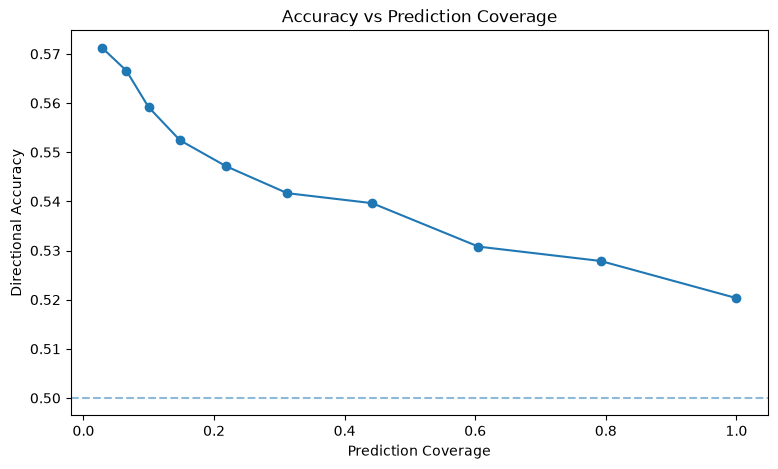

In [24]:
plt.figure(figsize=(9, 5))

plt.plot(
    confidence_df["Coverage"],
    confidence_df["Accuracy"],
    marker="o"
)

plt.xlabel("Prediction Coverage")
plt.ylabel("Directional Accuracy")

plt.title(
    "Accuracy vs Prediction Coverage"
)

plt.axhline(
    0.5,
    linestyle="--",
    alpha=0.5
)

plt.show()

In [25]:
# ============================================================
# 17. UP VS DOWN CONFIDENCE SIGNAL ANALYSIS
# ============================================================

signal_results = []

for margin in [
    0.03,
    0.04,
    0.05,
    0.06,
    0.07,
    0.08,
    0.10
]:

    lower = 0.50 - margin
    upper = 0.50 + margin

    # ------------------------------------------
    # UP signals
    # ------------------------------------------

    up_mask = val_prob >= upper

    if up_mask.sum() > 0:

        up_y = y_val.iloc[
            np.where(up_mask)[0]
        ]

        up_accuracy = (
            up_y == 1
        ).mean()

    else:
        up_accuracy = np.nan


    # ------------------------------------------
    # DOWN signals
    # ------------------------------------------

    down_mask = val_prob <= lower

    if down_mask.sum() > 0:

        down_y = y_val.iloc[
            np.where(down_mask)[0]
        ]

        down_accuracy = (
            down_y == 0
        ).mean()

    else:
        down_accuracy = np.nan


    signal_results.append({

        "Margin": margin,

        "Lower": lower,
        "Upper": upper,

        "UP_Signals":
            up_mask.sum(),

        "UP_Accuracy":
            up_accuracy,

        "DOWN_Signals":
            down_mask.sum(),

        "DOWN_Accuracy":
            down_accuracy,

        "Total_Signals":
            up_mask.sum()
            + down_mask.sum(),

        "Coverage":
            (
                up_mask.sum()
                + down_mask.sum()
            ) / len(y_val)
    })


signal_analysis_df = pd.DataFrame(
    signal_results
)

signal_analysis_df

,Margin,Lower,Upper,UP_Signals,UP_Accuracy,DOWN_Signals,DOWN_Accuracy,Total_Signals,Coverage
0,0.03,0.47,0.53,5718,0.529556,3831,0.554685,9549,0.442001
1,0.04,0.46,0.54,4188,0.534862,2556,0.552817,6744,0.312164
2,0.05,0.45,0.55,3089,0.540628,1630,0.559509,4719,0.218432
3,0.06,0.44,0.56,2170,0.542396,1025,0.573659,3195,0.147889
4,0.07,0.43,0.57,1484,0.549865,671,0.579732,2155,0.099750
5,0.08,0.42,0.58,1012,0.565217,407,0.570025,1419,0.065682
6,0.10,0.40,0.60,463,0.591793,162,0.512346,625,0.028930
